# Практическая работа 2. Нейронные сети

**Работу выполнил (а):**

Карпова Алиса Станиславовна

## Текст задания

Необходимо по имеющимся данным о ценах на жильё предсказать окончательную цену каждого дома с учетом характеристик домов с использованием нейронной сети. Описание набора данных содержит 80 классов (набор переменых) классификации оценки типа жилья, и находится в файле data_description.txt.

В работе требуется дополнить раздел «Моделирование» в подразделе «Построение и обучение модели» создать и инициализировать последовательную модель нейронной сети с помощью фрэймворков тренировки нейронных сетей как: Torch или Tensorflow. Скомпилировать нейронную сеть выбрав функцию потерь и оптимизатор соответственно. Оценить точность полученных результатов. Вывести предсказанные данные о продаже.

## Ход выполнения задания


В первую очередь, импортируем библиотеки, считываем и подготавливаем данные, проверяем на пустыне значения, масштабируем:

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow
from tensorflow.python.keras.engine import data_adapter

def _is_distributed_dataset(ds):
    return isinstance(ds, data_adapter.input_lib.DistributedDatasetSpec)

data_adapter._is_distributed_dataset = _is_distributed_dataset


from tensorflow.python.keras.layers import Dense
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from tensorflow.python.keras.models import Sequential

train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

def missing_value_checker(data):
    list = []
    for feature, content in data.items():
        if data[feature].isnull().values.any():
            sum = data[feature].isna().sum()

            type = data[feature].dtype

            print(f'{feature}: {sum}, type: {type}')

            list.append(feature)
    print(list)
    print(len(list))

missing_value_checker(test_data)

test_edited = test_data.drop(['Alley','FireplaceQu','PoolQC', 'Fence', 'MiscFeature'], axis=1)
train_edited = train_data.drop(['Alley','FireplaceQu','PoolQC', 'Fence', 'MiscFeature'], axis=1)

def nan_filler(data):
    for label, content in data.items():
        if pd.api.types.is_numeric_dtype(content):
            data[label] = content.fillna(content.median())
        else:
            data[label] = content.astype("category").cat.as_ordered()
            data[label] = pd.Categorical(content).codes+1

nan_filler(test_edited)
nan_filler(train_edited)

missing_value_checker(test_edited)
missing_value_checker(train_edited)
train_edited.shape, test_edited.shape
test_edited.info()
train_edited.info()

X = train_edited.drop('SalePrice', axis=1)
y = train_edited['SalePrice']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2)

X_train.shape, test_edited.shape

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)


Далее определяем нашу функцию для создания модели. Сначала я опишу общий алгоритм, а затем перейду к результатам экспериментов с различными гиперпараметрами:

In [ ]:
def create_model(input_dim, hidden_layers, optimizer, loss):
    model = Sequential()
    tensorflow.random.set_seed(40)


    model.add(Dense(hidden_layers[0], input_dim=input_dim, activation='relu'))

    for units in hidden_layers[1:]:
        model.add(Dense(units, activation='relu'))

    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss=loss, metrics=['mae'])

    return model

Создаем модель, обучаем ее и выполняем предсказание:

In [ ]:
model = create_model(input_dim=X_train_scaled.shape[1], hidden_layers=[64, 32], optimizer='adam', loss='mse')

history = model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_data=(X_val_scaled, y_val))

y_val_pred = model.predict(X_val_scaled)

Выводим отчет, оцениваем результаты по разным метрикам, строим график зависимости MSE от количества эпох:

In [ ]:
predictions_df = pd.DataFrame({
    # 'True Values': test_data['Id'],
    'Predictions': y_val_pred.flatten()
})


print(predictions_df.head())

mae = mean_absolute_error(y_val, y_val_pred)
mse = mean_squared_error(y_val, y_val_pred)
r2 = r2_score(y_val, y_val_pred)

print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Mean Absolute Error over epochs')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

Теперь можем попробовать использовать различные гиперпараметры. Попробуем изменять количество слоев и количество нейронов на них.

1. Слои: [64, 32]

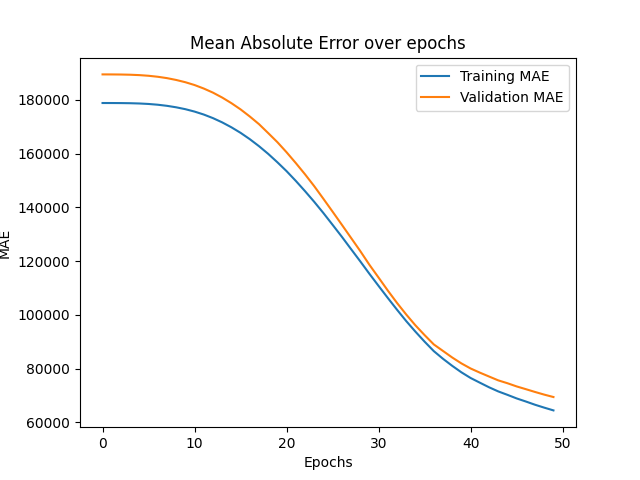


```
     Predictions
0  114109.195312
1  167162.000000
2   40291.921875
3  270106.187500
4   56642.468750
Mean Absolute Error: 69438.359375
Mean Squared Error: 6997590528.0
R-squared: 0.026624679565429688
```


2. Слои: [64, 32, 16]

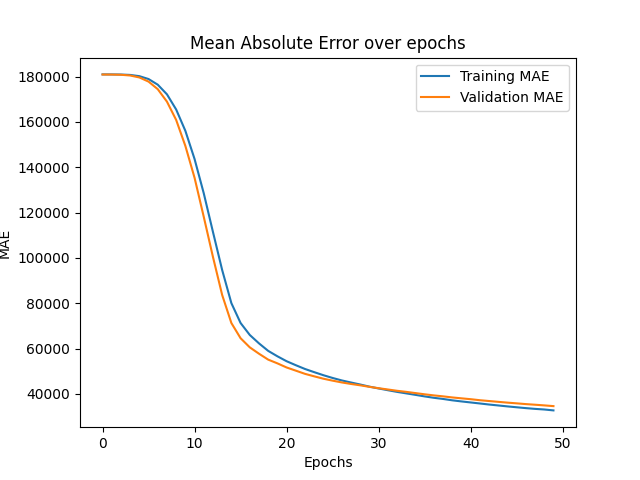

```
     Predictions
0   33517.585938
1  147357.218750
2  341989.781250
3  109125.429688
4  205547.640625
Mean Absolute Error: 34590.0078125
Mean Squared Error: 2008072448.0
R-squared: 0.6294225454330444
```

3. Слои: [64, 32, 32, 32, 16]

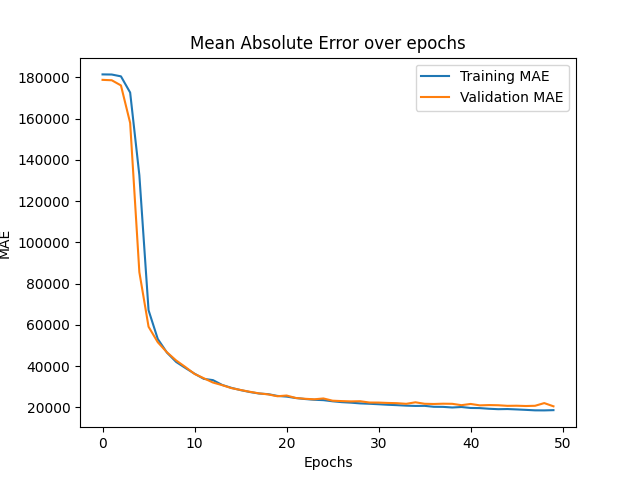

```
     Predictions
0  180435.906250
1  216060.343750
2  130258.203125
3  109981.265625
4  162569.125000
Mean Absolute Error: 20563.876953125
Mean Squared Error: 750696704.0
R-squared: 0.8673459887504578
```

4. Слои = [128, 128, 64, 32, 32, 32, 16, 16]

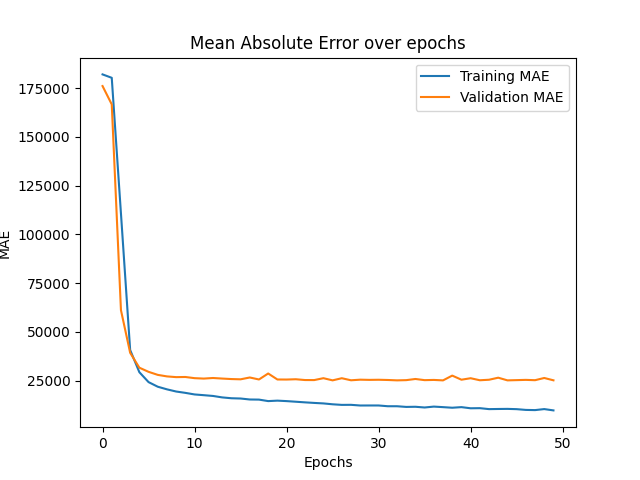

```
     Predictions
0  233773.328125
1  107919.703125
2  148352.234375
3  191855.453125
4  157702.796875
Mean Absolute Error: 25133.548828125
Mean Squared Error: 6257311744.0
R-squared: -0.11499655246734619
```

5. Слои = [128, 128, 64, 64, 32, 32, 32, 32, 16, 16, 16]

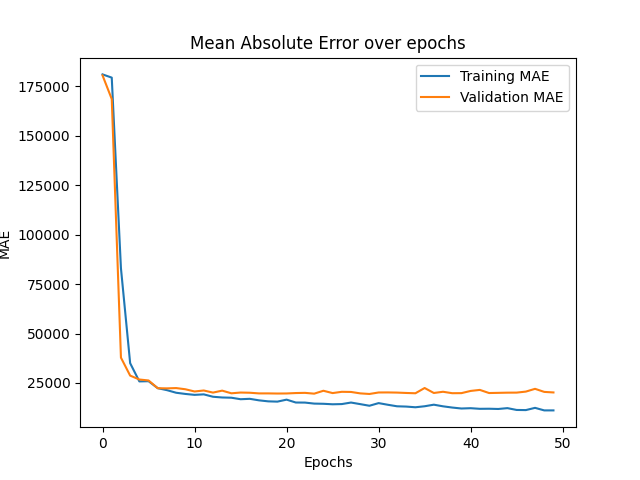

```
     Predictions
0  143259.437500
1  101653.625000
2  111267.726562
3  117957.609375
4  414809.031250
Mean Absolute Error: 20219.701171875
Mean Squared Error: 992304576.0
R-squared: 0.8530481457710266
```

Можем попробовать сделать выводы о влиянии количества скрытых слоев и количества нейронов на них на эффективность работы сети. Из исследованных комбинаций наилучшие результаты показали слои [64, 32, 32, 32, 16]. Поначалу при увеличении количества слоев ошибка уменьшалась, но затем она снова начала расти.

Когда сеть состоит из одного или нескольких скрытых слоев, она может научиться только относительно простым паттернам в данных. Можно предположить, что такие сети подходят для задач, где связи между входами и выходами являются линейными или слабо нелинейными.

В случае увеличения числа скрытых слоев, сеть становится глубокой. Такие сети способны моделировать более сложные зависимости и абстракции в данных, что может повысить точность на сложных задачах, но, как мы увидели особенно в 4-ом случае, увеличение количества слоев может привести к переобучению. На графике видно, что ошибка на тренировочных данных заметно меньше, чем на тестовых.

Если в скрытых слоях будет мало нейронов, модель будет иметь ограниченную способность обучаться и обнаруживать паттерны в данных. Это может привести к недостаточной точности. Увеличение числа нейронов в скрытых слоях увеличивает способность модели выучить более сложные представления. Но если нейронов слишком много, модель может стать склонной к переобучению, особенно если данных мало.

Теперь же попробуем поэкспериментировать с количеством эпох. Для этого будем использовать скрытые слои, показавшие наилучшие результаты в предыдущем пункте.

1. 10 эпох

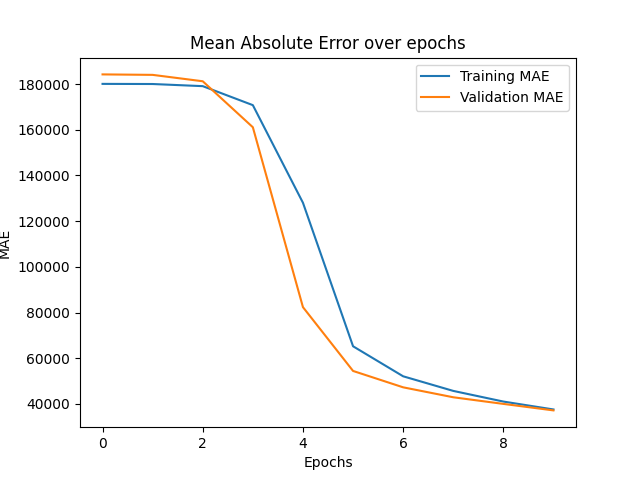

```
     Predictions
0  103448.929688
1  136056.484375
2   87113.640625
3  156724.468750
4  184383.437500
Mean Absolute Error: 37170.80859375
Mean Squared Error: 2310159360.0
R-squared: 0.703850269317627
```

2. 50 эпох

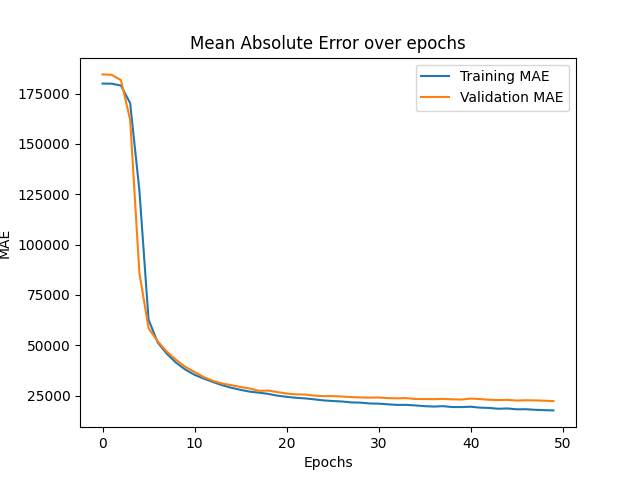

```
    Predictions
0  147902.03125
1   81670.53125
2  143500.43750
3  318897.34375
4  164992.81250
Mean Absolute Error: 22227.513671875
Mean Squared Error: 1094944256.0
R-squared: 0.8496013879776001
```

3. 100 эпох

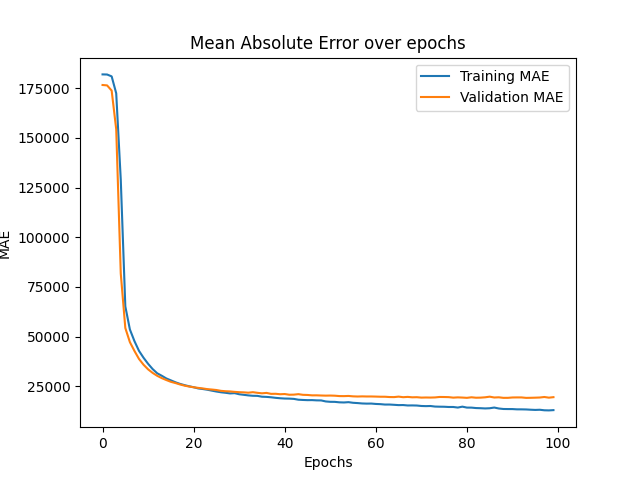

```
     Predictions
0  114489.546875
1   80804.726562
2  126251.250000
3   91863.601562
4  129781.320312
Mean Absolute Error: 19491.076171875
Mean Squared Error: 1167085184.0
R-squared: 0.790521502494812
```

4. 150 эпох

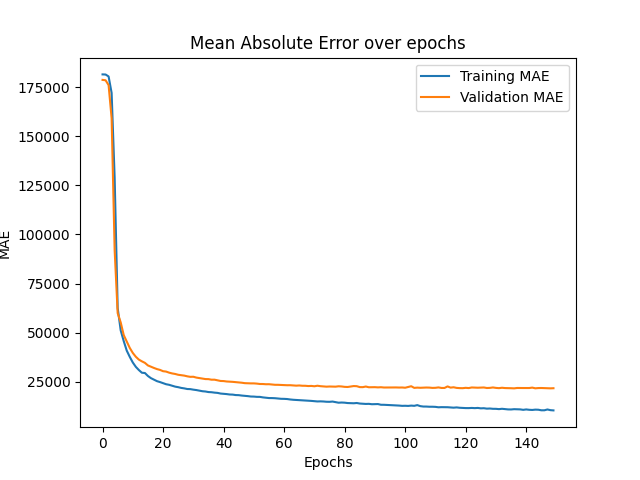

```
     Predictions
0  139238.843750
1  124666.664062
2  225283.218750
3   77625.867188
4  249200.812500
Mean Absolute Error: 19989.78515625
Mean Squared Error: 1210364160.0
R-squared: 0.7991576194763184
```

Попробуем сделать выводы о влиянии количества эпох на результат.

Эпохи — это количество полных проходов через весь обучающий набор данных, которые модель делает в процессе обучения. В каждой эпохе модель обновляет свои параметры на основе ошибки, полученной при сравнении предсказаний с истинными значениями.

Когда количество эпох слишком маленькое, модель не будет достаточно обучена, и ошибка на тестовых данных останется высокой, модель не успевает выучить основные зависимости в данных, потому что параметры модели обновляются слишком мало раз (видно на первом примере где количество эпох равно 10).

Когда количество эпох слишком велико, модель начала переобучаться, как на последнем примере. В этом случае можем увидеть, что ошибка на обучающих данных продолжает уменьшаться, но ошибка на тестовых данных увеличивается, поскольку модель начинает "запоминать" шум и особенности обучающего набора, которые не являются универсальными.

Теперь попробуем изменять количество нейронов только на входном уровне:

1. 256 нейронов

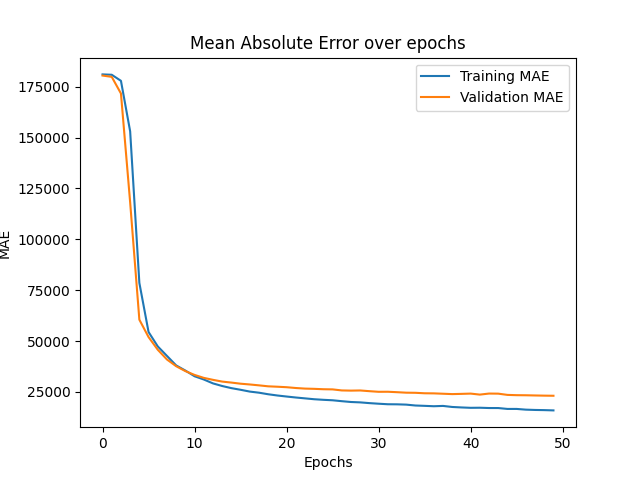

```
     Predictions
0  171745.125000
1  211370.359375
2  186605.937500
3   84748.195312
4  208426.734375
Mean Absolute Error: 23114.095703125
Mean Squared Error: 1992742784.0
R-squared: 0.7367598414421082
```

2. 128 нейронов

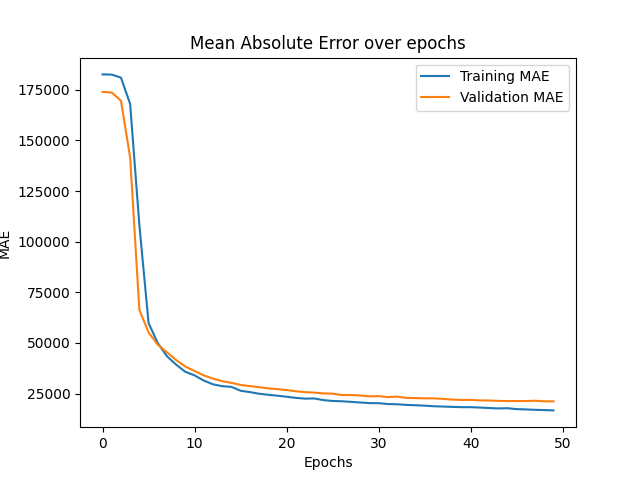

```
     Predictions
0  117149.734375
1  174009.031250
2  256346.281250
3  246960.609375
4  174346.453125
Mean Absolute Error: 21143.78125
Mean Squared Error: 1285749632.0
R-squared: 0.757382333278656
```

3. 64 нейрона

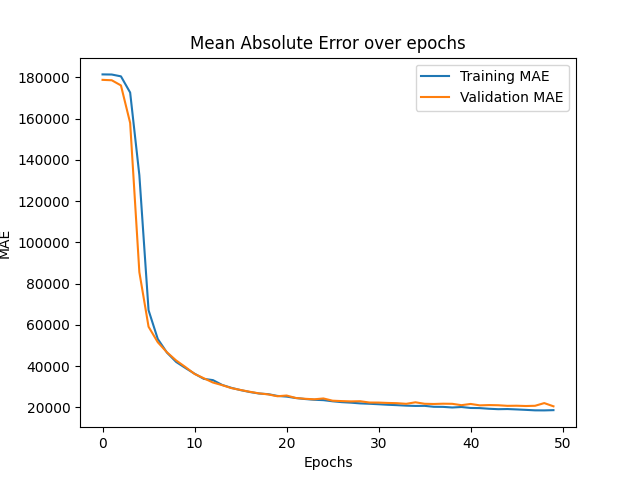

```
     Predictions
0  180435.906250
1  216060.343750
2  130258.203125
3  109981.265625
4  162569.125000
Mean Absolute Error: 20563.876953125
Mean Squared Error: 750696704.0
R-squared: 0.8673459887504578
```

4. 32 нейрона

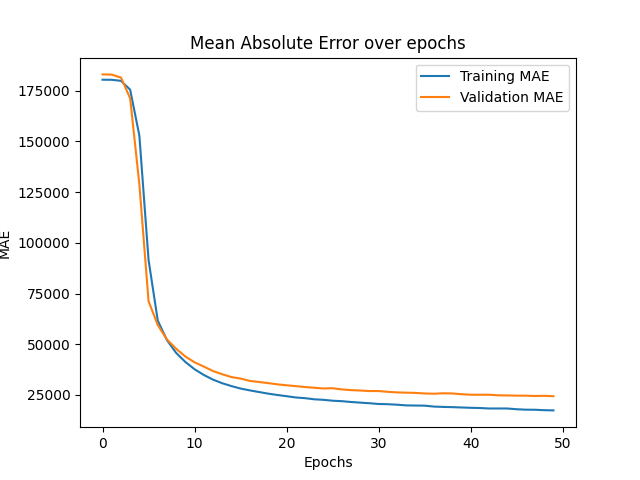

```
     Predictions
0  145798.328125
1  284119.562500
2  197344.140625
3  127555.468750
4  284883.093750
Mean Absolute Error: 24390.73046875
Mean Squared Error: 3300117504.0
R-squared: 0.46935248374938965
```

Постараемся проанализировать результаты.

Входной слой — это не слой, который "обрабатывает" или "учит" модель, он просто передает данные в сеть. Его основная функция — принять входные данные и передать их на последующие слои.

Количество нейронов во входном слое напрямую зависит от количества признаков в данных.

Если количество нейронов во входном слое меньше, чем количество признаков в данных, то не получится передать все данные на вход модели, и это вызовет ошибку, как на последнем примере.

Большое количество нейронов в скрытых слоях может повысить мощность модели и ее способность обрабатывать сложные зависимости, но также увеличивает риск переобучения, что мы и видим в первом примере.

Таким образом, мы видим наилучшие результаты при 64 нейронах во входном слое, что максимально близко к количеству входрных признаков.


Теперь попробуем изменять размеры мини-выборки.

1. batch_size=16

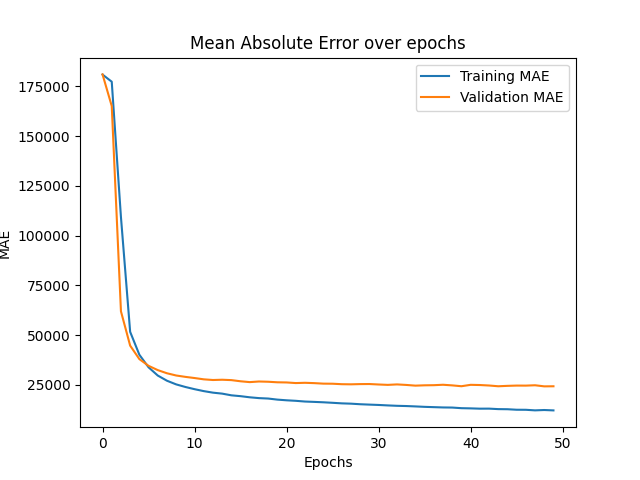

```
     Predictions
0  141928.453125
1  143884.109375
2  378983.562500
3  267280.781250
4  130609.992188
Mean Absolute Error: 24317.640625
Mean Squared Error: 5522442752.0
R-squared: 0.14470744132995605
```

2. batch_size=32

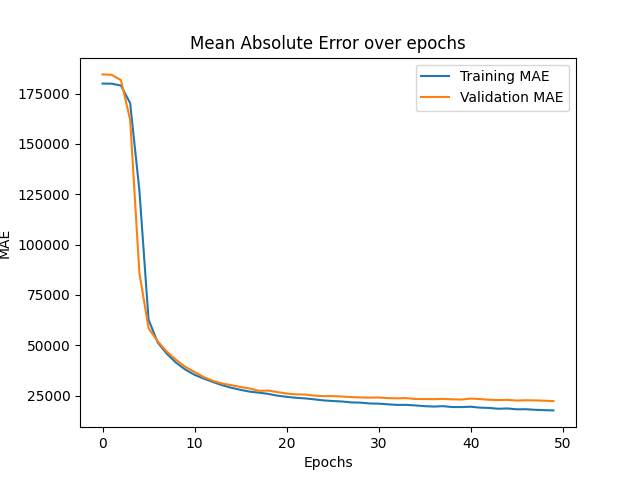

```
    Predictions
0  147902.03125
1   81670.53125
2  143500.43750
3  318897.34375
4  164992.81250
Mean Absolute Error: 22227.513671875
Mean Squared Error: 1094944256.0
R-squared: 0.8496013879776001
```

3. batch_size=64

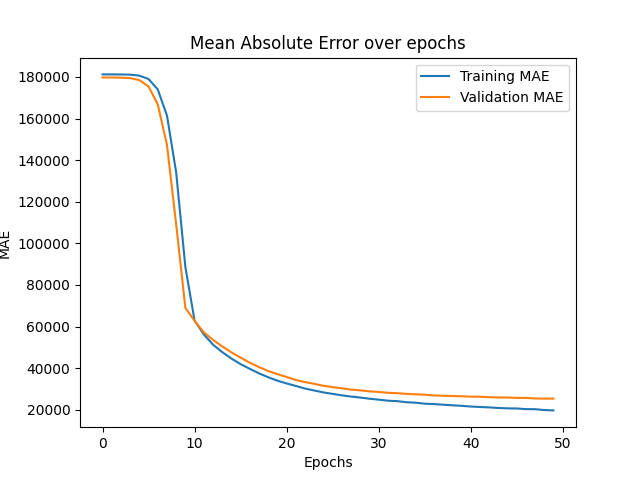

```
     Predictions
0   97615.093750
1  126353.101562
2  216404.953125
3  169129.171875
4  163501.093750
Mean Absolute Error: 25402.345703125
Mean Squared Error: 3410507264.0
R-squared: 0.4429425597190857
```

4. batch_size=128

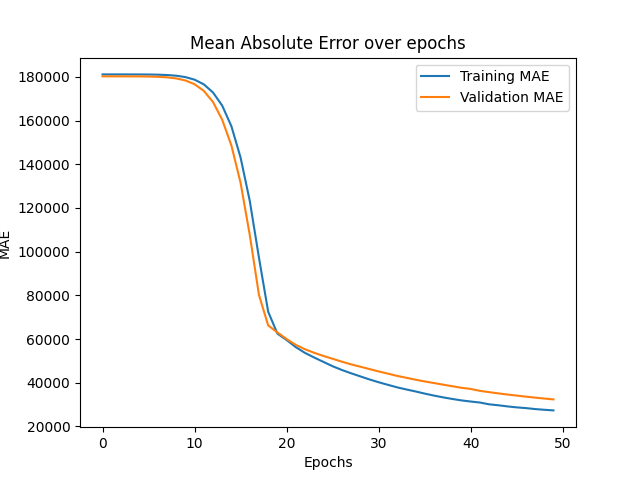

```
    Predictions
0  1.201127e+05
1  1.269733e+05
2  1.073006e+05
3  1.456187e+05
4  1.008915e+06
Mean Absolute Error: 32391.908203125
Mean Squared Error: 4063674624.0
R-squared: 0.3785473704338074
```

5. batch_size=256

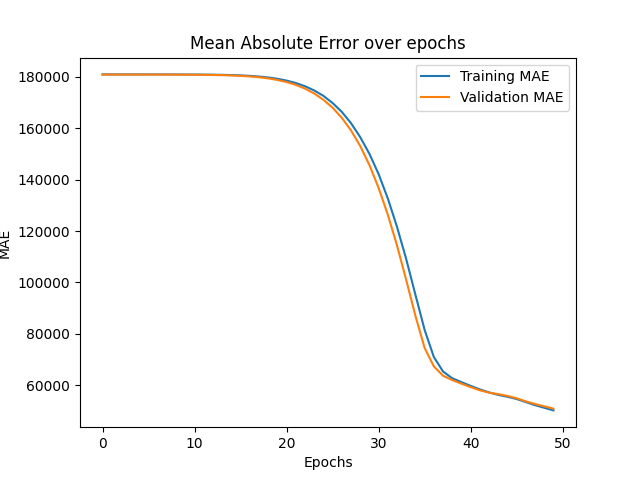

```
     Predictions
0  128965.820312
1   65564.437500
2  194790.343750
3   82442.625000
4  131585.546875
Mean Absolute Error: 50908.81640625
Mean Squared Error: 4374092288.0
R-squared: 0.2354094386100769
```

Batch size определяет, сколько примеров из обучающего набора данных используется для одной итерации обновления весов в процессе обучения нейронной сети. По сути, это количество примеров, которые модель обрабатывает за один раз перед тем, как обновит свои параметры. Как мы видим, оптимальный результат был достигнут при batch size = 32, далее модель начала переобучаться.




Теперь попробуем изменить оптимизатор. Во всех предыдущих примерах я указывала optimizer='adam'.

Adam — это усовершенствованный вариант градиентного спуска, который адаптирует скорость обучения для каждого параметра и учитывает как текущие, так и предыдущие обновления. Это помогает улучшить эффективность и ускорить сходимость.

- Momentum (Импульс): Это метод, который использует прошлые градиенты для "памяти" и ускоряет движение в сторону минимизации. Он помогает сгладить колебания градиента и ускорить процесс обучения.

- Адаптивная коррекция скорости обучения: Adam адаптирует скорость обучения для каждого параметра, вычисляя первый момент (среднее значение градиентов) и второй момент (среднее значение квадратов градиентов) для каждого параметра. Это помогает более эффективно обновлять веса.

Теперь попробуем использовать в качестве оптимизатора optimizer='rmsprop'.

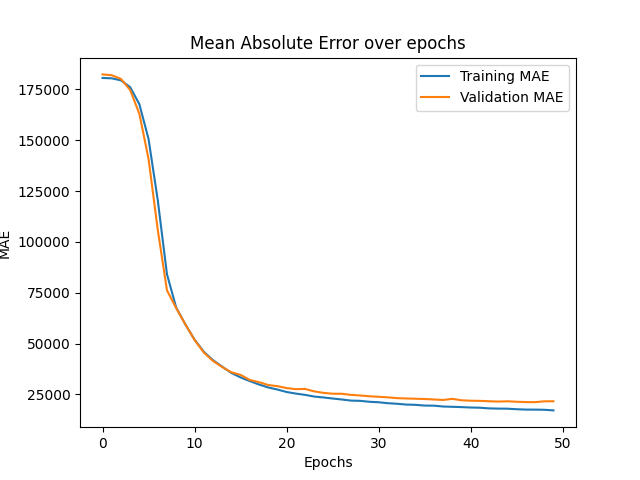

```
     Predictions
0  235786.546875
1  110451.531250
2  455868.343750
3  211507.406250
4  152227.093750
Mean Absolute Error: 21669.169921875
Mean Squared Error: 1434372992.0
R-squared: 0.7269734740257263
```

Видим, что

Теперь попробуем изменить параметр loss на mae.

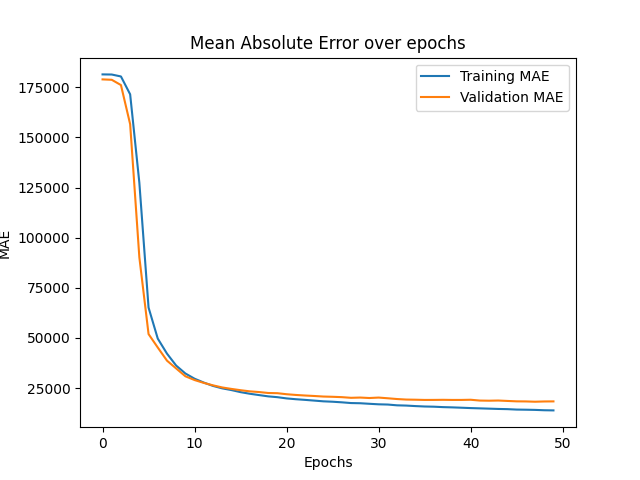

```
     Predictions
0  226620.406250
1   74289.296875
2  136713.312500
3  157140.078125
4  249264.578125
Mean Absolute Error: 18337.486328125
Mean Squared Error: 684553792.0
R-squared: 0.8796597123146057
```

##Выводы

Я предсказала цены домов с учетом характеристик домов с использованием нейронной сети.
С использованием нейронной сети я предсказала цены на дома, поэкспериментировала с различными гиперпараметрами используемой модели с делала выводы о их влиянии на результат.

Среди всех исследованных гиперпараметров самыми эффективными оказались:

```
Слои: [64, 32, 32, 32, 16]
Эпохи: 50
Размер мини-выборки: 64
Loss: mse
Optimizer: adam
```